# Maximum Likelihood Estimation for SIR Parameters

In this notebook, we estimate the SIR model parameters using the maximum likelihood method.

We use synthetic observations of infected individuals \( I_{\text{obs}}(t) \), generated from the SIR model with Gaussian noise.

The goal is to estimate:
- infection rate \( \beta \)
- recovery rate \( \gamma \)

under the assumption that the observation error is Gaussian.

## 1. Import libraries and set path

We import required libraries and add the project root to Python path
so that modules in `src` can be used.

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model import solve_sir
from src.estimation import estimate_parameters_mle

## 2. Load synthetic data

We load the synthetic data generated in the previous notebook.

In [3]:
df = pd.read_csv("../data/synthetic_sir.csv")
df.head()

,t,I_obs
0,0.0,5.967142
1,1.0,-0.161665
2,2.0,7.967508
3,3.0,17.049870
4,4.0,-0.120784


## 3. Define observed data and initial conditions

We assume that only the infected population is observed.

We also specify the initial conditions used in the SIR simulation.

In [4]:
t = df["t"].values
I_obs = df["I_obs"].values

S0 = 999
I0 = 1
R0 = 0

beta_true = 0.3
gamma_true = 0.1
sigma = 10.0

## 4. Likelihood formulation

We assume that the observation model is

\[
I_{\text{obs}}(t) = I_{\text{model}}(t; \beta, \gamma) + \varepsilon_t,
\]

where

\[
\varepsilon_t \sim \mathcal{N}(0, \sigma^2).
\]

Under this Gaussian error assumption, the likelihood is determined by the discrepancy
between the observed infected trajectory and the model-generated trajectory.

In practice, we minimize the negative log-likelihood.

## 5. Run maximum likelihood estimation

We numerically optimize the negative log-likelihood
to estimate \( \beta \) and \( \gamma \).

In [5]:
mle_result = estimate_parameters_mle(
    t=t,
    I_obs=I_obs,
    S0=S0,
    I0=I0,
    R0=R0,
    sigma=sigma,
    beta_init=0.2,
    gamma_init=0.2
)

mle_result

{'beta_hat': np.float64(0.2997890396789455),
 'gamma_hat': np.float64(0.10072176945765642),
 'success': True,
 'fun': np.float64(366.731595925294),
 'result':   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 366.731595925294
         x: [ 2.998e-01  1.007e-01]
       nit: 7
       jac: [-1.239e-03  1.285e-03]
      nfev: 57
      njev: 19
  hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>}

## 6. Extract estimated parameters

In [6]:
beta_hat = mle_result["beta_hat"]
gamma_hat = mle_result["gamma_hat"]

print(f"Estimated beta  : {beta_hat:.4f}")
print(f"Estimated gamma : {gamma_hat:.4f}")
print(f"True beta       : {beta_true:.4f}")
print(f"True gamma      : {gamma_true:.4f}")

Estimated beta  : 0.2998
Estimated gamma : 0.1007
True beta       : 0.3000
True gamma      : 0.1000


## 7. Simulate the fitted SIR model

Using the estimated parameters, we simulate the SIR model again
and compare the fitted trajectory with the observations.

In [7]:
S_fit, I_fit, R_fit = solve_sir(beta_hat, gamma_hat, S0, I0, R0, t)
S_true, I_true, R_true = solve_sir(beta_true, gamma_true, S0, I0, R0, t)

## 8. Compare true trajectory, observations, and fitted trajectory

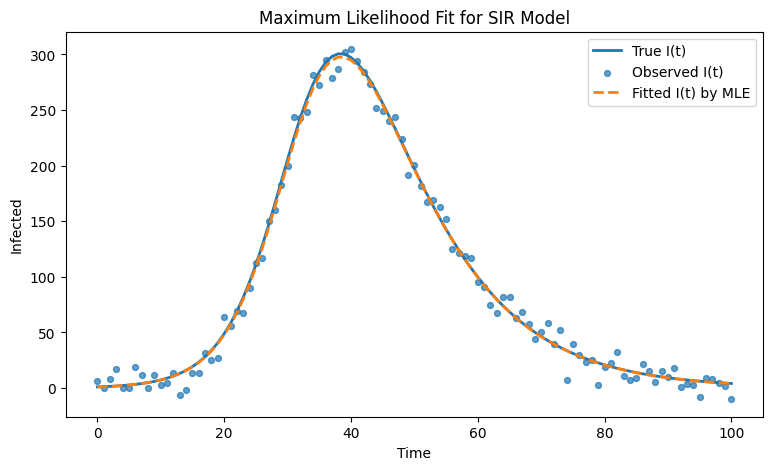

In [8]:
plt.figure(figsize=(9, 5))

plt.plot(t, I_true, label="True I(t)", linewidth=2)
plt.scatter(t, I_obs, label="Observed I(t)", s=18, alpha=0.7)
plt.plot(t, I_fit, label="Fitted I(t) by MLE", linewidth=2, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Infected")
plt.title("Maximum Likelihood Fit for SIR Model")
plt.legend()
plt.show()

## 9. Compare parameter values

In [9]:
comparison_df = pd.DataFrame({
    "parameter": ["beta", "gamma"],
    "true_value": [beta_true, gamma_true],
    "estimated_value": [beta_hat, gamma_hat]
})

comparison_df

,parameter,true_value,estimated_value
0,beta,0.3,0.299789
1,gamma,0.1,0.100722


## 10. Interpretation

If the fitted trajectory is close to the observed data
and the estimated parameters are close to the true values,
then maximum likelihood estimation works well for this toy example.

Because we assumed Gaussian observation noise,
the MLE result is expected to be very similar to the least squares result.

In more general settings, MLE provides a flexible framework because
we can change the observation model, for example:
- Poisson likelihood
- Negative binomial likelihood
- other data-generating assumptions

## 11. Optional note: relation to least squares

Under Gaussian observation noise with fixed variance,
maximum likelihood estimation is closely related to least squares estimation.

This is why the estimated parameters from LS and MLE are often very similar in this example.